# Phase 7 Visualization Notebook

KuaiRecLargeStrictPosV2_0.2 / phase7_router_aux_v1

중복 규칙: 동일 setting+seed는 최신 timestamp run 채택

In [1]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)

REPO = Path("/workspace/jy1559/FMoE")
NORMAL_ROOT = REPO / "experiments/run/artifacts/results/fmoe_n3/normal/phase7_router_aux_v1/P7/KuaiRecLargeStrictPosV2_0.2/FMoEN3"
LOG_ROOT = REPO / "experiments/run/artifacts/logging/fmoe_n3/KuaiRecLargeStrictPosV2_0.2/P7"
PAT = re.compile(r"_p7_(aux_)?(r\d+_[a-z_]+)_s([0-9]+)_")

SETTING_LABEL = {
    "r0_std": "R0_STD", "r1_fac": "R1_FAC", "r2_fac_heavy": "R2_FAC_HEAVY", "r3_fac_only": "R3_FAC_ONLY",
    "r4_hir": "R4_HIR", "r5_fac_group": "R5_FAC_GROUP", "r6_fac_only_both": "R6_FAC_ONLY_BOTH", "r7_fac_heavy_feat": "R7_FAC_HEAVY_FEAT",
    "r0_std_bal_a": "AUX_R0_STD_BAL_A", "r0_std_bal_b": "AUX_R0_STD_BAL_B", "r0_std_spec_a": "AUX_R0_STD_SPEC_A", "r0_std_spec_b": "AUX_R0_STD_SPEC_B",
    "r2_fac_heavy_bal_a": "AUX_R2_FAC_HEAVY_BAL_A", "r2_fac_heavy_bal_b": "AUX_R2_FAC_HEAVY_BAL_B", "r2_fac_heavy_spec_a": "AUX_R2_FAC_HEAVY_SPEC_A", "r2_fac_heavy_spec_b": "AUX_R2_FAC_HEAVY_SPEC_B",
}

def parse_setting(kind, setting_raw):
    router_variant = setting_raw.split("_")[0].upper()
    aux_variant = "BASE"
    if kind == "aux":
        if setting_raw.endswith("bal_a"): aux_variant = "BAL_A"
        elif setting_raw.endswith("bal_b"): aux_variant = "BAL_B"
        elif setting_raw.endswith("spec_a"): aux_variant = "SPEC_A"
        elif setting_raw.endswith("spec_b"): aux_variant = "SPEC_B"
    aux_family = "none" if aux_variant == "BASE" else ("balance" if aux_variant.startswith("BAL") else "specialization")
    router_anchor = ""
    if kind == "aux":
        router_anchor = "standard(R0)" if router_variant == "R0" else "factored-heavy(R2)"
    return router_variant, aux_variant, aux_family, router_anchor

latest = {}
for p in sorted(NORMAL_ROOT.glob("*.json")):
    m = PAT.search(p.name)
    if not m:
        continue
    kind = "aux" if m.group(1) else "router"
    setting_raw = m.group(2)
    seed = int(m.group(3))
    payload = json.loads(p.read_text())
    key = (kind, setting_raw, seed)
    if key not in latest or payload.get("timestamp","") > latest[key]["timestamp"]:
        latest[key] = {"path": p, "timestamp": payload.get("timestamp",""), "payload": payload}

rows, sp_rows, dg_rows = [], [], []
for (kind, setting_raw, seed), info in sorted(latest.items()):
    payload = info["payload"]
    stem = info["path"].stem
    router_variant, aux_variant, aux_family, router_anchor = parse_setting(kind, setting_raw)
    rows.append({
        "run_stem": stem,
        "timestamp": info["timestamp"],
        "seed_id": seed,
        "experiment_group": "aux_reg" if kind == "aux" else "router_core",
        "setting_raw": setting_raw,
        "setting_id": SETTING_LABEL.get(setting_raw, setting_raw.upper()),
        "router_variant": router_variant,
        "aux_variant": aux_variant,
        "aux_family": aux_family,
        "router_anchor": router_anchor,
        "valid_best_mrr20": float(payload.get("best_mrr@20") or 0.0),
        "test_mrr20": float(payload.get("test_mrr@20") or 0.0),
    })

    run_dir = LOG_ROOT / stem
    sp_path = run_dir / "special_metrics.json"
    if sp_path.exists():
        sp = json.loads(sp_path.read_text())
        test = (sp.get("test_special_metrics") or {})
        slices = test.get("slices") or {}
        pop = (slices.get("target_popularity_abs") or {}).get("<=5") or {}
        sess = slices.get("session_len") or {}
        sp_rows.append({
            "run_stem": stem,
            "cold_item_mrr20": float(pop.get("mrr@20")) if pop.get("mrr@20") is not None else np.nan,
            "cold_item_count": int(pop.get("count") or 0),
            "sess_1_2_mrr20": float((sess.get("1-2") or {}).get("mrr@20")) if (sess.get("1-2") or {}).get("mrr@20") is not None else np.nan,
            "sess_1_2_count": int(((sess.get("1-2") or {}).get("count")) or 0),
            "sess_3_5_mrr20": float((sess.get("3-5") or {}).get("mrr@20")) if (sess.get("3-5") or {}).get("mrr@20") is not None else np.nan,
            "sess_3_5_count": int(((sess.get("3-5") or {}).get("count")) or 0),
            "sess_6_10_mrr20": float((sess.get("6-10") or {}).get("mrr@20")) if (sess.get("6-10") or {}).get("mrr@20") is not None else np.nan,
            "sess_6_10_count": int(((sess.get("6-10") or {}).get("count")) or 0),
            "sess_11p_mrr20": float((sess.get("11+") or {}).get("mrr@20")) if (sess.get("11+") or {}).get("mrr@20") is not None else np.nan,
            "sess_11p_count": int(((sess.get("11+") or {}).get("count")) or 0),
        })

    dg_path = run_dir / "diag_best_valid_overview.json"
    if dg_path.exists():
        dg = json.loads(dg_path.read_text())
        for st in dg.get("stages", []):
            stage = str(st.get("stage",""))
            dg_rows.append({
                "run_stem": stem,
                "stage": stage,
                "stage_short": stage.split("@")[0] if "@" in stage else stage,
                "n_eff": float(st.get("n_eff") or 0.0),
                "cv_usage": float(st.get("cv_usage") or 0.0),
                "top1_max_frac": float(st.get("top1_max_frac") or 0.0),
                "route_jitter_adjacent": float(st.get("route_jitter_adjacent") or 0.0),
                "route_consistency_knn_score": float(st.get("route_consistency_knn_score") or 0.0),
                "family_top_expert_mean_share": float(st.get("family_top_expert_mean_share") or 0.0),
            })

df_runs = pd.DataFrame(rows)
df_special = pd.DataFrame(sp_rows)
df_diag_stage = pd.DataFrame(dg_rows)

df_runs = df_runs.merge(df_special, on="run_stem", how="left")
df_diag_stage = df_diag_stage.merge(df_runs[["run_stem","valid_best_mrr20","test_mrr20","experiment_group","router_variant","aux_variant","aux_family","router_anchor"]], on="run_stem", how="left")

# aux anchor용 집계 프레임
base_anchor = df_runs[(df_runs["experiment_group"]=="router_core") & (df_runs["router_variant"].isin(["R0","R2"]))].copy()
base_anchor["aux_family"] = "none"
base_anchor["aux_variant"] = "BASE"
base_anchor["router_anchor"] = base_anchor["router_variant"].map({"R0":"standard(R0)","R2":"factored-heavy(R2)"})

df_aux_anchor = pd.concat([
    df_runs[df_runs["experiment_group"]=="aux_reg"].copy(),
    base_anchor.copy(),
], ignore_index=True)

# 논문 메시지용 요약
dg_macro = df_diag_stage.groupby("run_stem", as_index=False)[["n_eff","route_jitter_adjacent","family_top_expert_mean_share"]].mean()
df_paper_claim = df_runs.merge(dg_macro, on="run_stem", how="left")
df_paper_claim = df_paper_claim.groupby(["experiment_group","router_variant","aux_family"], as_index=False)[
    ["valid_best_mrr20","test_mrr20","cold_item_mrr20","sess_3_5_mrr20","n_eff","route_jitter_adjacent","family_top_expert_mean_share"]
].mean()

print("df_runs", df_runs.shape)
print("df_special", df_special.shape)
print("df_diag_stage", df_diag_stage.shape)
print("df_aux_anchor", df_aux_anchor.shape)
print("df_paper_claim", df_paper_claim.shape)

df_runs (64, 22)
df_special (64, 11)
df_diag_stage (168, 16)
df_aux_anchor (40, 22)
df_paper_claim (12, 10)


## 2) 품질 점검 (64개 커버리지, dedup, 누락)

In [2]:
check = df_runs.groupby(["experiment_group","setting_id"]).seed_id.nunique().reset_index(name="n_seeds")
print("total runs:", len(df_runs))
print("expected 64 ->", len(df_runs)==64)
print("all settings have 4 seeds ->", bool((check["n_seeds"]==4).all()))
print("special missing:", int(df_runs["cold_item_mrr20"].isna().sum()))
print("diag missing runs:", int(df_runs["run_stem"].nunique() - df_diag_stage["run_stem"].nunique()))
check.sort_values(["experiment_group","setting_id"])

total runs: 64
expected 64 -> True
all settings have 4 seeds -> True
special missing: 8
diag missing runs: 8


,experiment_group,setting_id,n_seeds
0,aux_reg,AUX_R0_STD_BAL_A,4
1,aux_reg,AUX_R0_STD_BAL_B,4
2,aux_reg,AUX_R0_STD_SPEC_A,4
3,aux_reg,AUX_R0_STD_SPEC_B,4
4,aux_reg,AUX_R2_FAC_HEAVY_BAL_A,4
5,aux_reg,AUX_R2_FAC_HEAVY_BAL_B,4
6,aux_reg,AUX_R2_FAC_HEAVY_SPEC_A,4
7,aux_reg,AUX_R2_FAC_HEAVY_SPEC_B,4
8,router_core,R0_STD,4
9,router_core,R1_FAC,4


## 3) Router 8종 성능 요약 (기본)

/tmp/ipykernel_59951/2790123342.py:8: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


,setting_id,router_variant,valid_best_mrr20_max,valid_best_mrr20_mean,valid_best_mrr20_var,test_mrr20_max,test_mrr20_mean,test_mrr20_var
0,R0_STD,R0,0.0812,0.081150,3.333333e-09,0.1622,0.162125,2.500000e-09
2,R2_FAC_HEAVY,R2,0.0811,0.080975,9.166667e-09,0.1616,0.161500,6.666667e-09
1,R1_FAC,R1,0.0807,0.080625,2.500000e-09,0.1623,0.162025,4.916667e-08
7,R7_FAC_HEAVY_FEAT,R7,0.0807,0.080625,2.500000e-09,0.1621,0.162000,1.333333e-08
5,R5_FAC_GROUP,R5,0.0806,0.080600,0.000000e+00,0.1624,0.162125,7.583333e-08
3,R3_FAC_ONLY,R3,0.0804,0.080375,2.500000e-09,0.1616,0.161425,1.583333e-08
4,R4_HIR,R4,0.0803,0.080300,0.000000e+00,0.1617,0.161650,1.000000e-08
6,R6_FAC_ONLY_BOTH,R6,0.0803,0.080175,1.583333e-08,0.1614,0.161225,1.583333e-08


/venv/FMoE/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/venv/FMoE/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


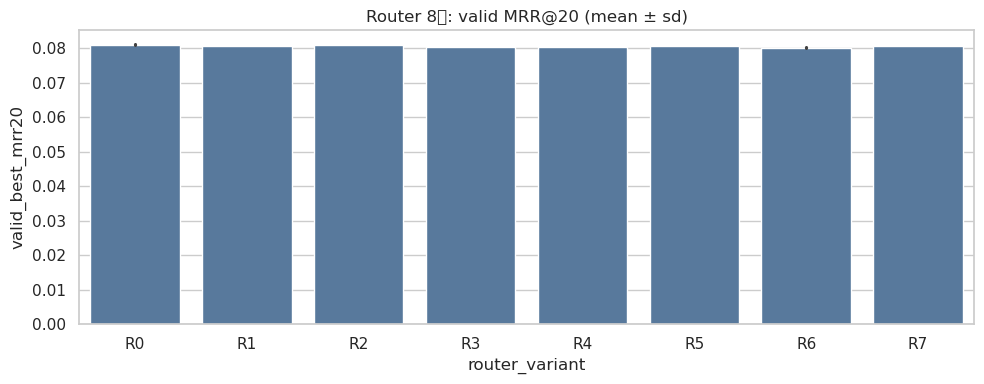

In [3]:
router = df_runs[df_runs["experiment_group"]=="router_core"].copy()
summary_router = router.groupby(["setting_id","router_variant"], as_index=False)[["valid_best_mrr20","test_mrr20"]].agg(["max","mean","var"])
summary_router.columns = ["_".join(c).strip("_") for c in summary_router.columns]
summary_router = summary_router.reset_index(drop=True).sort_values("valid_best_mrr20_mean", ascending=False)
plt.figure(figsize=(10,4))
sns.barplot(data=router, x="router_variant", y="valid_best_mrr20", estimator=np.mean, errorbar="sd", color="#4c78a8")
plt.title("Router 8종: valid MRR@20 (mean ± sd)")
plt.tight_layout()
summary_router

## 4) Aux 8종 성능 요약 (기본)

/tmp/ipykernel_59951/1860262765.py:8: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


,setting_id,router_variant,aux_variant,aux_family,valid_best_mrr20_max,valid_best_mrr20_mean,valid_best_mrr20_var,test_mrr20_max,test_mrr20_mean,test_mrr20_var
1,AUX_R0_STD_BAL_B,R0,BAL_B,balance,0.0814,0.081325,9.166667e-09,0.1622,0.162000,2.000000e-08
2,AUX_R0_STD_SPEC_A,R0,SPEC_A,specialization,0.0814,0.081325,2.500000e-09,0.1621,0.161950,1.666667e-08
0,AUX_R0_STD_BAL_A,R0,BAL_A,balance,0.0813,0.081225,9.166667e-09,0.1621,0.162025,9.166667e-09
3,AUX_R0_STD_SPEC_B,R0,SPEC_B,specialization,0.0811,0.081100,0.000000e+00,0.1621,0.161800,6.666667e-08
5,AUX_R2_FAC_HEAVY_BAL_B,R2,BAL_B,balance,0.0810,0.080975,2.500000e-09,0.1619,0.161725,4.916667e-08
4,AUX_R2_FAC_HEAVY_BAL_A,R2,BAL_A,balance,0.0810,0.080900,6.666667e-09,0.1618,0.161500,6.000000e-08
6,AUX_R2_FAC_HEAVY_SPEC_A,R2,SPEC_A,specialization,0.0809,0.080800,2.000000e-08,0.1618,0.161675,9.166667e-09
7,AUX_R2_FAC_HEAVY_SPEC_B,R2,SPEC_B,specialization,0.0804,0.080350,3.333333e-09,0.1617,0.161550,1.666667e-08


/venv/FMoE/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/venv/FMoE/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


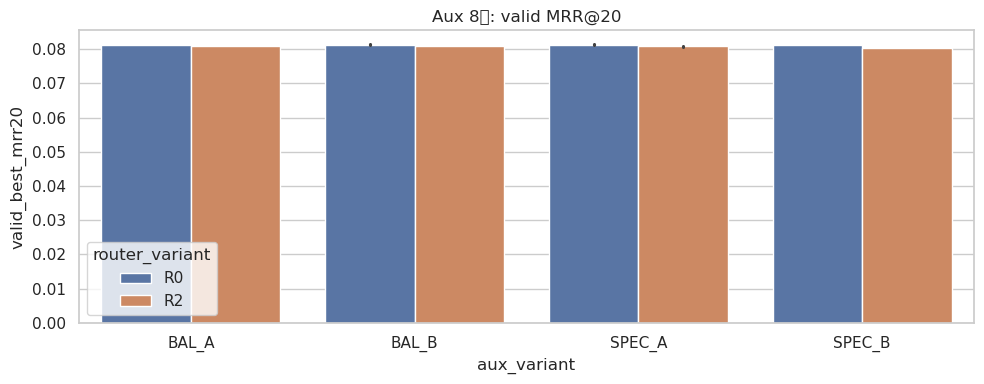

In [4]:
aux = df_runs[df_runs["experiment_group"]=="aux_reg"].copy()
summary_aux = aux.groupby(["setting_id","router_variant","aux_variant","aux_family"], as_index=False)[["valid_best_mrr20","test_mrr20"]].agg(["max","mean","var"])
summary_aux.columns = ["_".join(c).strip("_") for c in summary_aux.columns]
summary_aux = summary_aux.reset_index(drop=True).sort_values("valid_best_mrr20_mean", ascending=False)
plt.figure(figsize=(10,4))
sns.barplot(data=aux, x="aux_variant", y="valid_best_mrr20", hue="router_variant", estimator=np.mean, errorbar="sd")
plt.title("Aux 8종: valid MRR@20")
plt.tight_layout()
summary_aux

## 5) Aux 메인 분석: Anchor별 none/balance/specialization

/tmp/ipykernel_59951/1260465702.py:5: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_59951/1260465702.py:5: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_59951/1260465702.py:5: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


,router_anchor,aux_family,valid_best_mrr20,test_mrr20
1,factored-heavy(R2),none,0.080975,0.161500
0,factored-heavy(R2),balance,0.080937,0.161612
2,factored-heavy(R2),specialization,0.080575,0.161612
3,standard(R0),balance,0.081275,0.162013
5,standard(R0),specialization,0.081213,0.161875
4,standard(R0),none,0.081150,0.162125


/venv/FMoE/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/venv/FMoE/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/venv/FMoE/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/venv/FMoE/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/venv/FMoE/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/venv/FMoE/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: 

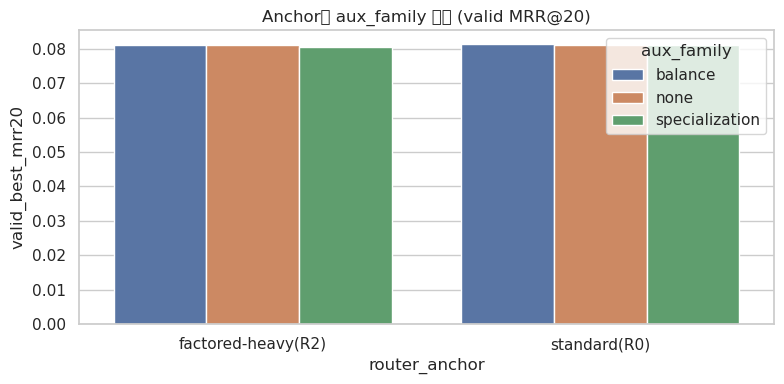

In [5]:
anchor_family = df_aux_anchor.groupby(["router_anchor","aux_family"], as_index=False)[["valid_best_mrr20","test_mrr20"]].mean()
plt.figure(figsize=(8,4))
sns.barplot(data=anchor_family, x="router_anchor", y="valid_best_mrr20", hue="aux_family")
plt.title("Anchor별 aux_family 비교 (valid MRR@20)")
plt.tight_layout()
anchor_family.sort_values(["router_anchor","valid_best_mrr20"], ascending=[True,False])

## 6) Anchor별 상세: BAL_A/B vs SPEC_A/B

/tmp/ipykernel_59951/3764695883.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, x="aux_variant", y="valid_best_mrr20", estimator=np.mean, errorbar="sd", ax=ax, palette="Set2")
/tmp/ipykernel_59951/3764695883.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, x="aux_variant", y="valid_best_mrr20", estimator=np.mean, errorbar="sd", ax=ax, palette="Set2")
/tmp/ipykernel_59951/3764695883.py:8: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_59951/3764695883.py:8: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_59951/376469

,router_anchor,aux_variant,valid_best_mrr20,test_mrr20
0,factored-heavy(R2),BAL_A,0.080900,0.161500
1,factored-heavy(R2),BAL_B,0.080975,0.161725
2,factored-heavy(R2),SPEC_A,0.080800,0.161675
3,factored-heavy(R2),SPEC_B,0.080350,0.161550
4,standard(R0),BAL_A,0.081225,0.162025
5,standard(R0),BAL_B,0.081325,0.162000
6,standard(R0),SPEC_A,0.081325,0.161950
7,standard(R0),SPEC_B,0.081100,0.161800


/venv/FMoE/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/venv/FMoE/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/venv/FMoE/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/venv/FMoE/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/venv/FMoE/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/venv/FMoE/lib/python3.10/site-packages/IPython/core/pylabtools.py:17

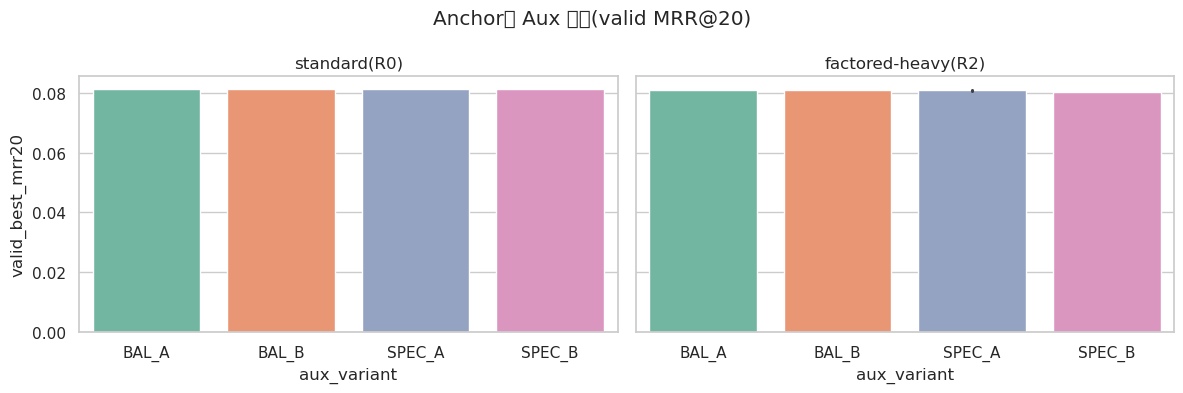

In [6]:
detail = df_aux_anchor[df_aux_anchor["aux_variant"].isin(["BAL_A","BAL_B","SPEC_A","SPEC_B"])].copy()
fig, axes = plt.subplots(1,2, figsize=(12,4), sharey=True)
for ax, anchor in zip(axes, ["standard(R0)","factored-heavy(R2)"]):
    sub = detail[detail["router_anchor"]==anchor]
    sns.barplot(data=sub, x="aux_variant", y="valid_best_mrr20", estimator=np.mean, errorbar="sd", ax=ax, palette="Set2")
    ax.set_title(anchor)
plt.suptitle("Anchor별 Aux 상세(valid MRR@20)")
plt.tight_layout()
detail.groupby(["router_anchor","aux_variant"])[["valid_best_mrr20","test_mrr20"]].mean().reset_index()

## 7) Special 핵심: cold / short-session anchor별 비교

,router_anchor,aux_family,cold_item_mrr20,sess_1_2_mrr20,sess_3_5_mrr20
0,factored-heavy(R2),balance,0.120163,0.000000,0.150920
1,factored-heavy(R2),none,0.119914,0.002042,0.150658
2,factored-heavy(R2),specialization,NaN,NaN,NaN
3,standard(R0),balance,0.121273,0.000408,0.151087
4,standard(R0),none,0.121095,0.003676,0.151782
5,standard(R0),specialization,0.121198,0.000000,0.151239


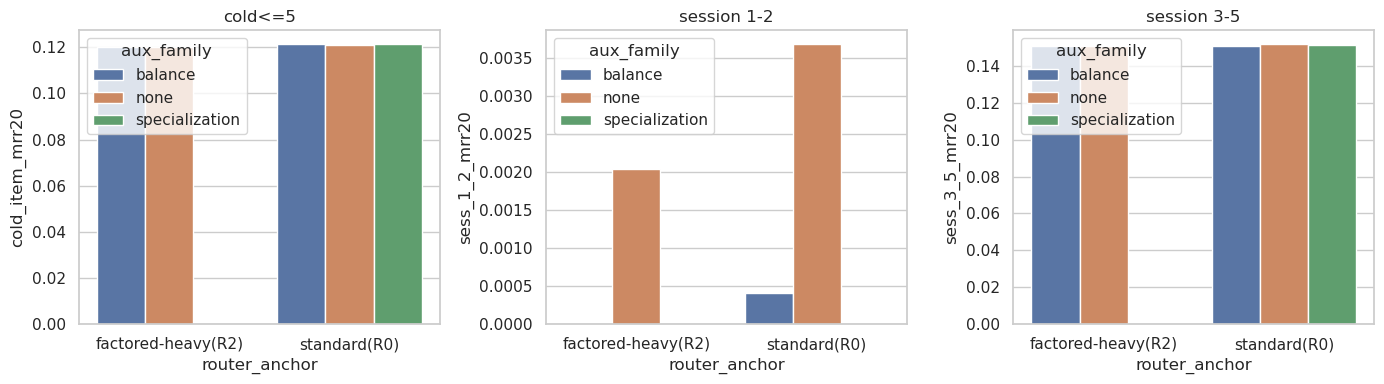

In [7]:
sp_anchor = df_aux_anchor.groupby(["router_anchor","aux_family"], as_index=False)[["cold_item_mrr20","sess_1_2_mrr20","sess_3_5_mrr20"]].mean()
fig, axes = plt.subplots(1,3, figsize=(14,4))
for ax, metric, title in zip(axes, ["cold_item_mrr20","sess_1_2_mrr20","sess_3_5_mrr20"], ["cold<=5","session 1-2","session 3-5"]):
    sns.barplot(data=sp_anchor, x="router_anchor", y=metric, hue="aux_family", ax=ax)
    ax.set_title(title)
plt.tight_layout()
sp_anchor

## 8) Special 신뢰도: slice count와 MRR 동시 확인

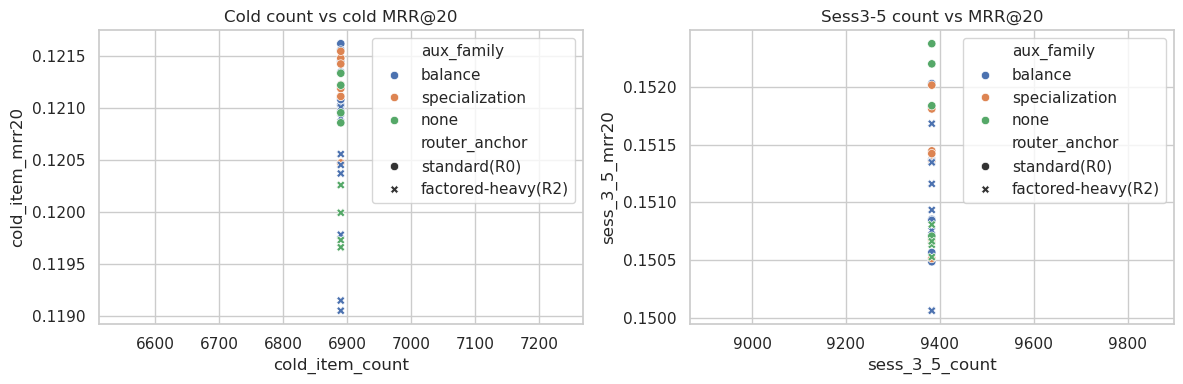

In [8]:
cnt_cols = ["cold_item_count","sess_1_2_count","sess_3_5_count"]
mrr_cols = ["cold_item_mrr20","sess_1_2_mrr20","sess_3_5_mrr20"]
rel = df_aux_anchor[["run_stem","router_anchor","aux_family"]+cnt_cols+mrr_cols].copy()
rel_long = rel.melt(id_vars=["run_stem","router_anchor","aux_family"], value_vars=cnt_cols+mrr_cols, var_name="metric", value_name="value")
rel_long.head()

fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.scatterplot(data=df_aux_anchor, x="cold_item_count", y="cold_item_mrr20", hue="aux_family", style="router_anchor", ax=axes[0])
axes[0].set_title("Cold count vs cold MRR@20")
sns.scatterplot(data=df_aux_anchor, x="sess_3_5_count", y="sess_3_5_mrr20", hue="aux_family", style="router_anchor", ax=axes[1])
axes[1].set_title("Sess3-5 count vs MRR@20")
plt.tight_layout()

## 9) Diag 전체 산점도: diag metric vs valid MRR@20 (64-run 기준 stage 포함)

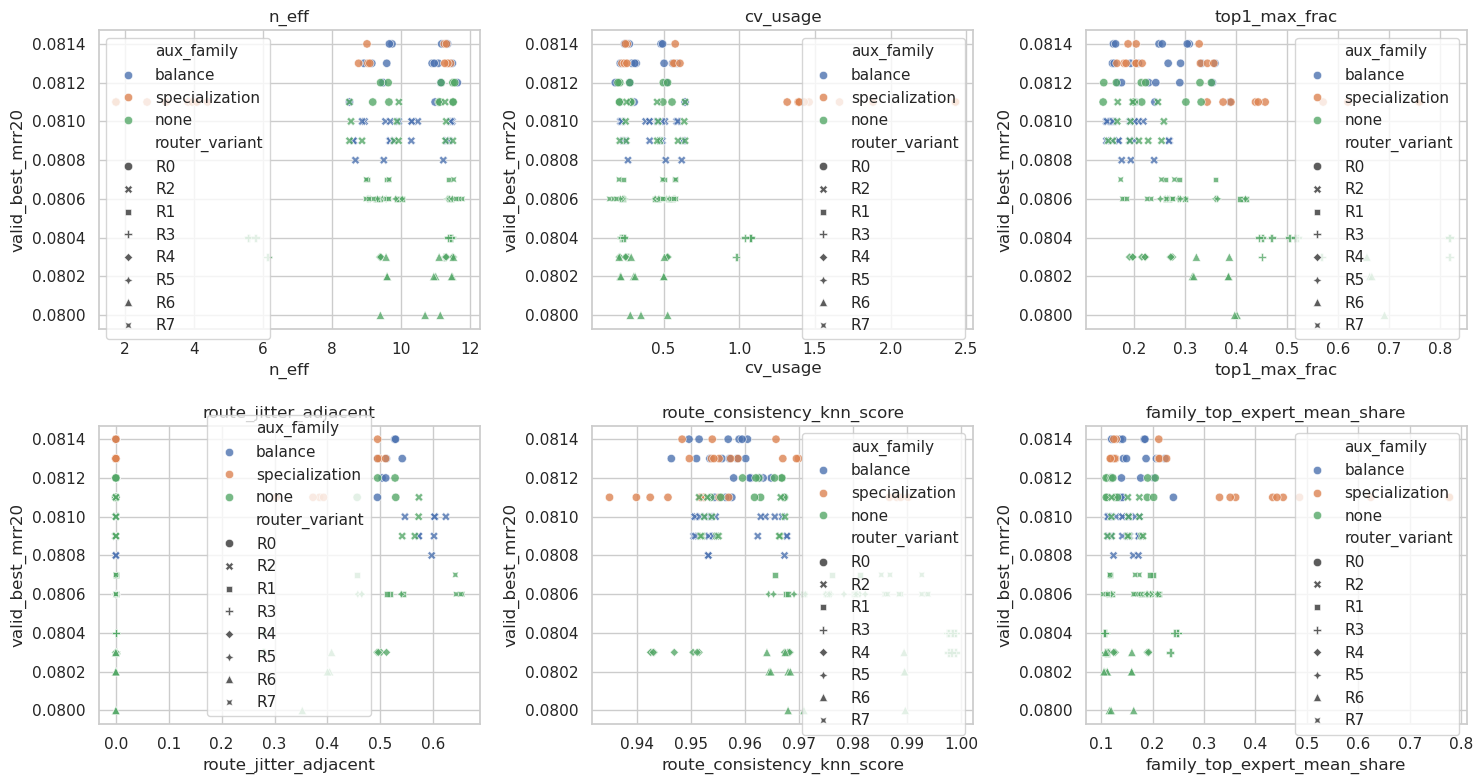

In [9]:
diag_metrics = ["n_eff","cv_usage","top1_max_frac","route_jitter_adjacent","route_consistency_knn_score","family_top_expert_mean_share"]
fig, axes = plt.subplots(2,3, figsize=(15,8))
for ax, m in zip(axes.flatten(), diag_metrics):
    sns.scatterplot(data=df_diag_stage, x=m, y="valid_best_mrr20", hue="aux_family", style="router_variant", alpha=0.8, ax=ax)
    ax.set_title(m)
plt.tight_layout()

## 10) Diag stage facet: macro/mid/micro별 scatter (색=aux_family, 마커=anchor)

/venv/FMoE/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


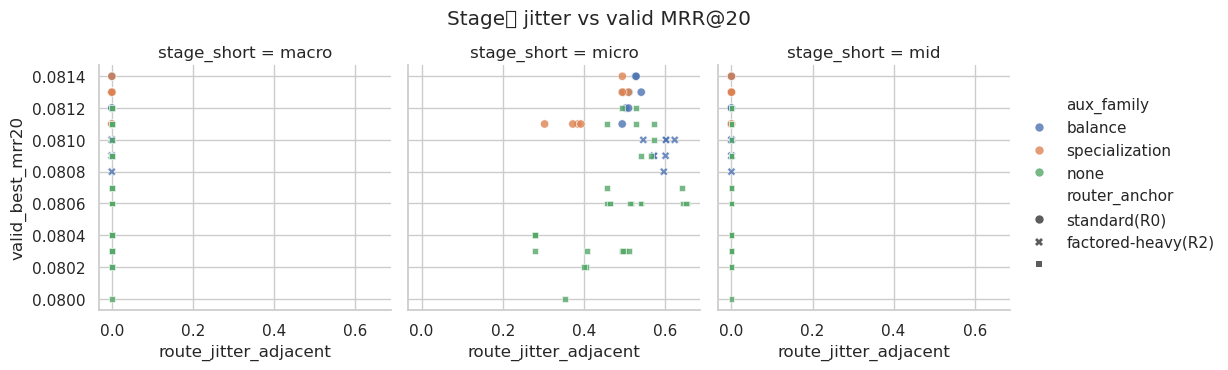

In [10]:
g = sns.relplot(
    data=df_diag_stage,
    x="route_jitter_adjacent", y="valid_best_mrr20",
    hue="aux_family", style="router_anchor",
    col="stage_short", kind="scatter",
    height=3.5, aspect=1.0, alpha=0.8
)
g.fig.suptitle("Stage별 jitter vs valid MRR@20", y=1.05)
plt.show()

## 11) Diag 조건부: standard-only subset (R0)

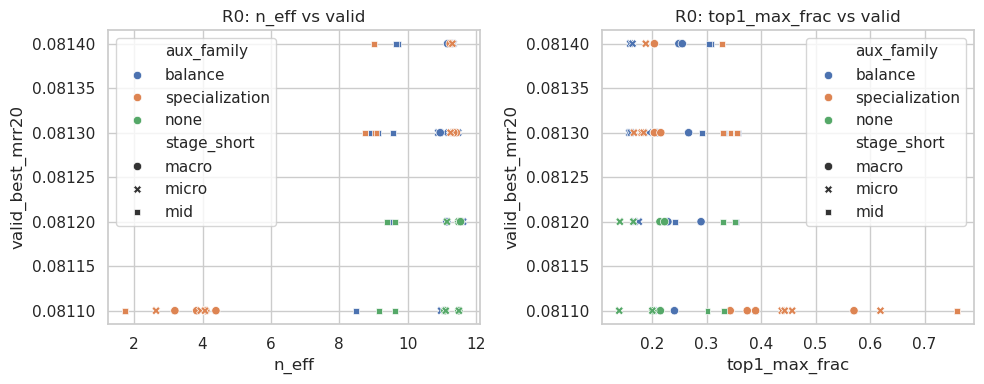

In [11]:
std_subset = df_diag_stage[df_diag_stage["router_variant"]=="R0"].copy()
fig, axes = plt.subplots(1,2, figsize=(10,4))
sns.scatterplot(data=std_subset, x="n_eff", y="valid_best_mrr20", hue="aux_family", style="stage_short", ax=axes[0])
axes[0].set_title("R0: n_eff vs valid")
sns.scatterplot(data=std_subset, x="top1_max_frac", y="valid_best_mrr20", hue="aux_family", style="stage_short", ax=axes[1])
axes[1].set_title("R0: top1_max_frac vs valid")
plt.tight_layout()

## 12) Diag 조건부: factored-heavy-only subset (R2)

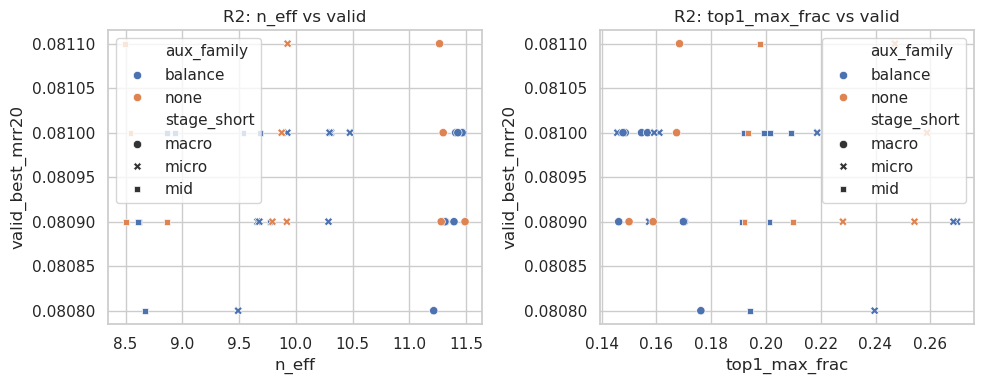

In [12]:
r2_subset = df_diag_stage[df_diag_stage["router_variant"]=="R2"].copy()
fig, axes = plt.subplots(1,2, figsize=(10,4))
sns.scatterplot(data=r2_subset, x="n_eff", y="valid_best_mrr20", hue="aux_family", style="stage_short", ax=axes[0])
axes[0].set_title("R2: n_eff vs valid")
sns.scatterplot(data=r2_subset, x="top1_max_frac", y="valid_best_mrr20", hue="aux_family", style="stage_short", ax=axes[1])
axes[1].set_title("R2: top1_max_frac vs valid")
plt.tight_layout()

## 13) Diag 분포: violin/box (핵심 지표)

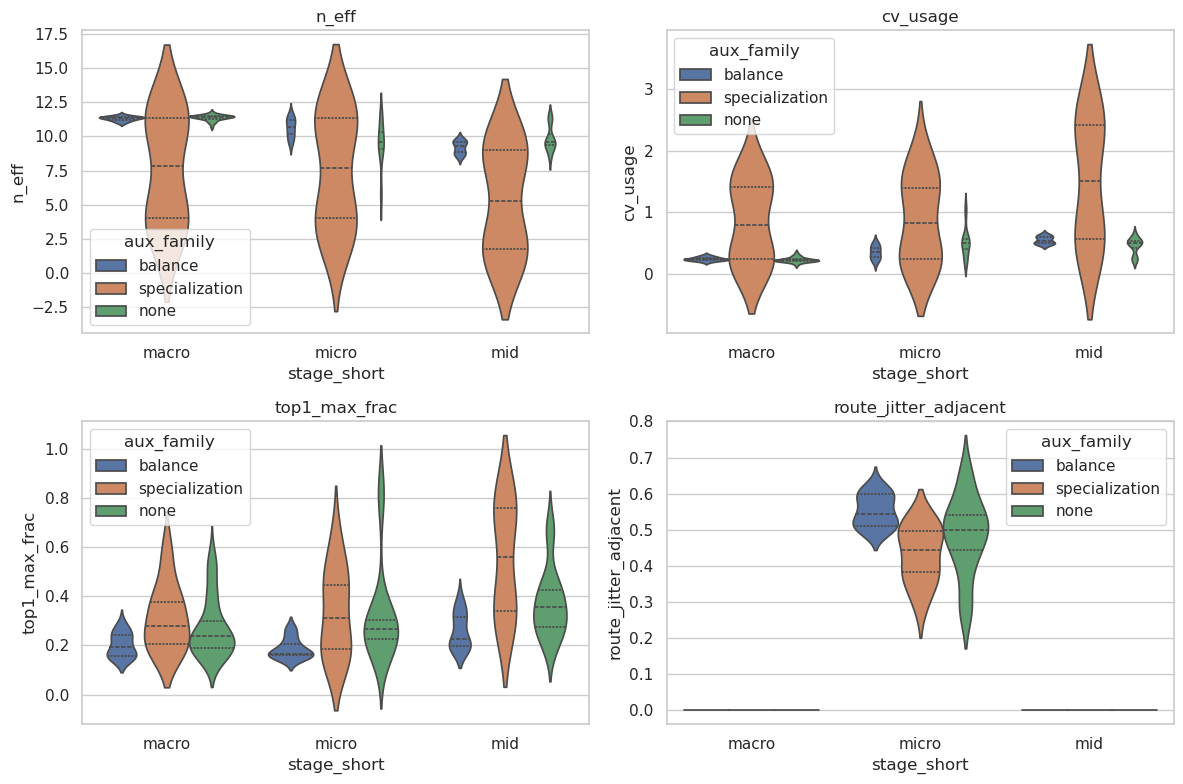

In [13]:
fig, axes = plt.subplots(2,2, figsize=(12,8))
for ax, m in zip(axes.flatten(), ["n_eff","cv_usage","top1_max_frac","route_jitter_adjacent"]):
    sns.violinplot(data=df_diag_stage, x="stage_short", y=m, hue="aux_family", split=False, inner="quart", ax=ax)
    ax.set_title(m)
plt.tight_layout()

## 14) 성능-특화 trade-off 맵

,run_stem,router_variant,aux_family,valid_best_mrr20,cold_item_mrr20,family_top_expert_mean_share,route_jitter_adjacent
0,KuaiRecLargeStrictPosV2_0.2_FeaturedMoE_N3_p7_...,R0,balance,0.0812,0.121348,0.147493,0.167835
1,KuaiRecLargeStrictPosV2_0.2_FeaturedMoE_N3_p7_...,R0,balance,0.0813,0.121108,0.159333,0.170475
2,KuaiRecLargeStrictPosV2_0.2_FeaturedMoE_N3_p7_...,R0,balance,0.0813,0.121622,0.156692,0.165080
3,KuaiRecLargeStrictPosV2_0.2_FeaturedMoE_N3_p7_...,R0,balance,0.0811,0.121562,0.173103,0.164873
4,KuaiRecLargeStrictPosV2_0.2_FeaturedMoE_N3_p7_...,R0,balance,0.0813,0.121032,0.152637,0.180520


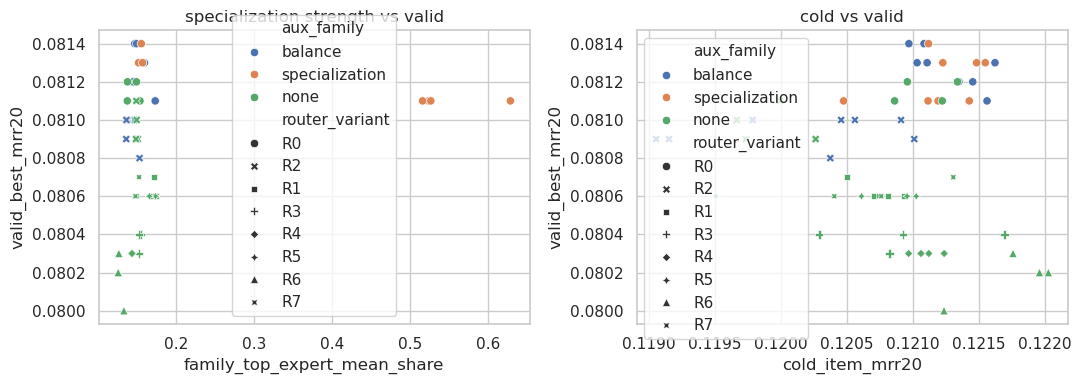

In [14]:
trade = df_runs.merge(
    df_diag_stage.groupby("run_stem", as_index=False)[["family_top_expert_mean_share","route_jitter_adjacent"]].mean(),
    on="run_stem", how="left"
)
fig, axes = plt.subplots(1,2, figsize=(11,4))
sns.scatterplot(data=trade, x="family_top_expert_mean_share", y="valid_best_mrr20", hue="aux_family", style="router_variant", ax=axes[0])
axes[0].set_title("specialization strength vs valid")
sns.scatterplot(data=trade, x="cold_item_mrr20", y="valid_best_mrr20", hue="aux_family", style="router_variant", ax=axes[1])
axes[1].set_title("cold vs valid")
plt.tight_layout()
trade[["run_stem","router_variant","aux_family","valid_best_mrr20","cold_item_mrr20","family_top_expert_mean_share","route_jitter_adjacent"]].head()

## 15) 논문용 Figure-ready 패널 (2x2)

/tmp/ipykernel_59951/1268067838.py:14: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_59951/1268067838.py:14: UserWarning: Glyph 45733 (\N{HANGUL SYLLABLE NEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_59951/1268067838.py:14: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_59951/1268067838.py:14: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_59951/1268067838.py:14: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_59951/1268067838.py:14: UserWarning: Glyph 50669 (\N{HANGUL SYLLABLE YEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_59951/1268067838.py:14: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.

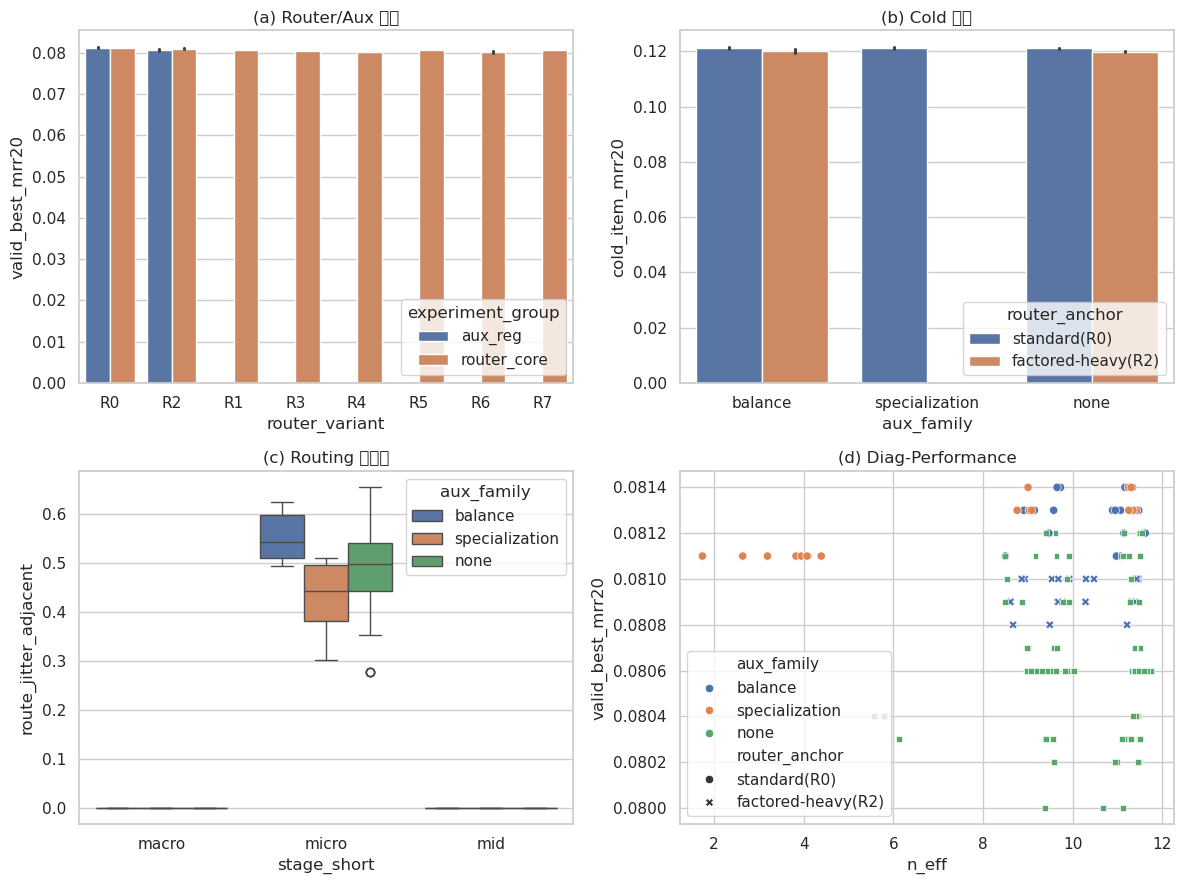

In [15]:
fig, axes = plt.subplots(2,2, figsize=(12,9))
# (1) 성능
sns.barplot(data=df_runs, x="router_variant", y="valid_best_mrr20", hue="experiment_group", estimator=np.mean, errorbar="sd", ax=axes[0,0])
axes[0,0].set_title("(a) Router/Aux 성능")
# (2) 특화
sns.barplot(data=df_aux_anchor, x="aux_family", y="cold_item_mrr20", hue="router_anchor", estimator=np.mean, errorbar="sd", ax=axes[0,1])
axes[0,1].set_title("(b) Cold 특화")
# (3) diag 분포
sns.boxplot(data=df_diag_stage, x="stage_short", y="route_jitter_adjacent", hue="aux_family", ax=axes[1,0])
axes[1,0].set_title("(c) Routing 동역학")
# (4) scatter
sns.scatterplot(data=df_diag_stage, x="n_eff", y="valid_best_mrr20", hue="aux_family", style="router_anchor", ax=axes[1,1])
axes[1,1].set_title("(d) Diag-Performance")
plt.tight_layout()

## 16) 탐색 섹션: 필터 함수 + 임의 scatter 템플릿

(32, 22) (72, 16)


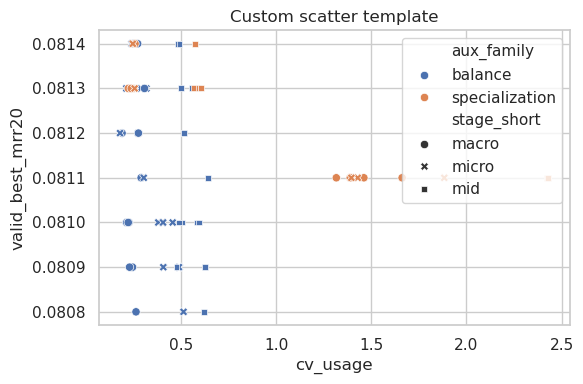

In [16]:
def filter_runs(router_variant=None, aux_family=None, stage=None, group=None):
    dfr = df_runs.copy()
    dfd = df_diag_stage.copy()
    if router_variant is not None:
        dfr = dfr[dfr["router_variant"].isin(router_variant if isinstance(router_variant, (list, tuple, set)) else [router_variant])]
        dfd = dfd[dfd["router_variant"].isin(router_variant if isinstance(router_variant, (list, tuple, set)) else [router_variant])]
    if aux_family is not None:
        dfr = dfr[dfr["aux_family"].isin(aux_family if isinstance(aux_family, (list, tuple, set)) else [aux_family])]
        dfd = dfd[dfd["aux_family"].isin(aux_family if isinstance(aux_family, (list, tuple, set)) else [aux_family])]
    if stage is not None:
        dfd = dfd[dfd["stage_short"].isin(stage if isinstance(stage, (list, tuple, set)) else [stage])]
    if group is not None:
        dfr = dfr[dfr["experiment_group"].isin(group if isinstance(group, (list, tuple, set)) else [group])]
        dfd = dfd[dfd["experiment_group"].isin(group if isinstance(group, (list, tuple, set)) else [group])]
    return dfr, dfd

# example
_sub_runs, _sub_diag = filter_runs(router_variant=["R0","R2"], aux_family=["balance","specialization"], stage=["macro","mid","micro"])
plt.figure(figsize=(6,4))
sns.scatterplot(data=_sub_diag, x="cv_usage", y="valid_best_mrr20", hue="aux_family", style="stage_short")
plt.title("Custom scatter template")
plt.tight_layout()
print(_sub_runs.shape, _sub_diag.shape)